In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [18]:
def conv_block(in_ch, out_ch, use_bn=False):
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
    ]
    if use_bn:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.extend([
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
    ])
    if use_bn:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        conv = lambda ch_in, ch_out: conv_block(ch_in, ch_out, use_bn=use_bn)

        # Encoder
        self.enc1 = conv(in_channels, 64)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = conv(64, 128)
        self.enc3 = conv(128, 256)
        self.enc4 = conv(256, 512)

        # Bottleneck
        self.bottleneck = conv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p  = self.pool(e1)
        e2 = self.enc2(p)
        p  = self.pool(e2)
        e3 = self.enc3(p)
        p  = self.pool(e3)
        e4 = self.enc4(p)
        p  = self.pool(e4)

        b = self.bottleneck(p)

        d4 = self.up4(b);  d4 = torch.cat([d4, e4], dim=1); d4 = self.dec4(d4)
        d3 = self.up3(d4); d3 = torch.cat([d3, e3], dim=1); d3 = self.dec3(d3)
        d2 = self.up2(d3); d2 = torch.cat([d2, e2], dim=1); d2 = self.dec2(d2)
        d1 = self.up1(d2); d1 = torch.cat([d1, e1], dim=1); d1 = self.dec1(d1)

        return self.final(d1)

In [4]:

class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [15]:
class Trainer:


    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
          transforms.Resize(config.image_size),
          transforms.ToTensor(),
          transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = None
        self.criterion = nn.BCEWithLogitsLoss()



        self.setup_dataloader()



    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)
    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [16]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8
    use_batchnorm = False          # ← новое поле

config = Config()

In [20]:

experiments = [
    {"name": "Base (lr=1e-4, bs=32, no BN)",    "lr": 1e-4, "bs": 32, "use_bn": False},
    {"name": "High LR (1e-3)",                  "lr": 1e-3, "bs": 32, "use_bn": False},
    {"name": "Small batch (bs=16)",             "lr": 1e-4, "bs": 16, "use_bn": False},
    {"name": "BatchNorm (лучшая версия)",       "lr": 1e-4, "bs": 32, "use_bn": True},
    {"name": "BN + lr=5e-4",                    "lr": 5e-4, "bs": 32, "use_bn": True},
]

results = []

for exp in experiments:
    print("\n" + "═"*70)
    print(f"▶️  Запуск: {exp['name']}")
    print("═"*70)

    cfg = Config()
    cfg.learning_rate = exp["lr"]
    cfg.batch_size = exp["bs"]
    cfg.use_batchnorm = exp["use_bn"]
    cfg.epochs = 7

    trainer = Trainer(cfg)

    model = UNet(in_channels=3, out_channels=1, use_bn=exp["use_bn"]).to(cfg.device)
    trainer.model = model
    trainer.optimizer = optim.Adam(trainer.model.parameters(), lr=cfg.learning_rate)

    trainer.run()

    test_loss, test_iou, test_f1 = trainer.test()

    results.append({
        "experiment": exp["name"],
        "lr": exp["lr"],
        "batch_size": exp["bs"],
        "batchnorm": exp["use_bn"],
        "test_loss": round(test_loss, 4),
        "test_iou":  round(test_iou,  4),
        "test_f1":   round(test_f1,   4),
    })

    print(f"   → Test IoU: {test_iou:.4f} | F1: {test_f1:.4f}\n")

# Таблица
import pandas as pd
df = pd.DataFrame(results)
df = df.sort_values("test_iou", ascending=False).reset_index(drop=True)
display(df.style.highlight_max(subset=["test_iou", "test_f1"], color="#90EE90"))


══════════════════════════════════════════════════════════════════════
▶️  Запуск: Base (lr=1e-4, bs=32, no BN)
══════════════════════════════════════════════════════════════════════


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:11<00:00,  2.02it/s]


Epoch 1 / 7, Train Loss: 0.6005, Val Loss: 0.5108, Val IoU: 0.6973, Val F1-score: 0.8174


100%|██████████| 23/23 [00:11<00:00,  2.04it/s]


Epoch 2 / 7, Train Loss: 0.4770, Val Loss: 0.4530, Val IoU: 0.7400, Val F1-score: 0.8449


...

100%|██████████| 115/115 [00:56<00:00,  2.04it/s]


Test Loss: 0.2181, Test IoU: 0.8709, Test F1-score: 0.9258


100%|██████████| 115/115 [00:57<00:00,  2.00it/s]

   → Test IoU: 0.8709 | F1: 0.9258



,experiment,lr,batch_size,batchnorm,test_loss,test_iou,test_f1
0,BN + lr=5e-4,0.000500,32,True,0.218100,0.870900,0.925800
1,BatchNorm (лучшая версия),0.000100,32,True,0.237000,0.863900,0.921900
2,Small batch (bs=16),0.000100,16,False,0.287900,0.838900,0.905800
3,"Base (lr=1e-4, bs=32, no BN)",0.000100,32,False,0.349800,0.801000,0.882100
4,High LR (1e-3),0.001000,32,False,0.411700,0.748000,0.849600


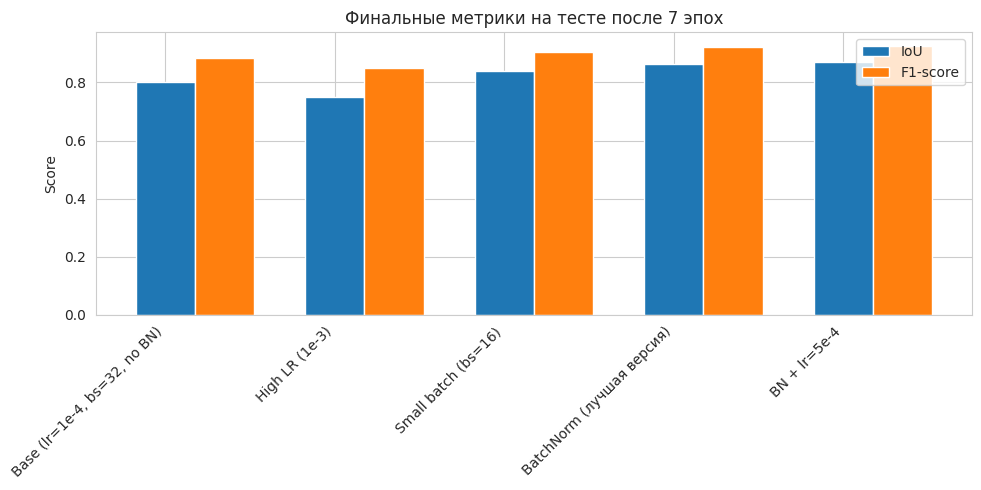

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df_plot = pd.DataFrame(results)


plt.figure(figsize=(10, 5))
x = df_plot["experiment"]
width = 0.35

plt.bar(x, df_plot["test_iou"], width, label="IoU", color="#1f77b4")
plt.bar([i + width for i in range(len(x))], df_plot["test_f1"], width, label="F1-score", color="#ff7f0e")

plt.ylabel("Score")
plt.title("Финальные метрики на тесте после 7 эпох")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


df_plot.round(4).to_csv("results_table.csv", index=False)


Добавление BatchNorm сильно улучшило результаты, потому что нормализация стабилизировала распределение активаций, ускорила сходимость и позволила использовать чуть более высокий learning rate без расхождения

Слишком большой learning rate (0.001) без нормализации привёл к нестабильному обучению и сильному недообучению